In [1]:
#import packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
import cartopy.crs as ccrs
import time
import matplotlib as mpl
from scipy.stats import linregress
# import dask
import matplotlib.ticker as mticker
import string
letters=[]
for letter in string.ascii_lowercase[0:24]:
    letters.append(letter+". ")
from functions import *
from scipy.stats import t
from scipy import stats

In [57]:
#functions
def cutcanada(dat):

    datout=dat.sel(latitude=slice(40,80), longitude=slice(-142.5,-55))

    return datout

#prepare mam only
def seas(dat, season):
    dat1=dat.sel(season=season)#-dat.sel(season='SON')
    dat2=dat1.stack(z={'latitude','longitude'})

    lat_radians = np.deg2rad(dat2.unstack().latitude)
    weights = np.cos(lat_radians)

    dat_weighted=dat2.unstack().weighted(weights).mean(("longitude", "latitude"))
    return dat_weighted 

def corsp(dat1,dat2):
    if not np.isnan(dat1).all() and not np.isnan(dat1).all():
        try:
            res = stats.pearsonr(dat1,dat2)
            slope=res[0]
            pval=res[1]
        except:
            slope=np.nan
            pval=np.nan
#         slope_td[i,j]=trend[-2]
#         pval_td[i,j]=trend[2]
    else:
        slope=np.nan
        pval=np.nan
    return slope, pval

def linereg (x,y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return slope,intercept




In [4]:
#read temperature trends
trseas_temphist=xr.open_dataset('cmip6_tas_day_hist2014_mktrends.nc').tas
trseas_temphist=trseas_temphist.assign_coords(models=models)
tmphist_midl=cutmidlat(trseas_temphist)
tmphist_lnd=landmask(tmphist_midl)

trseas_tmp_era=xr.open_dataset('era5_tmean_trend_final_1950-2014.nc').htdays
trseas_tmp_bk=xr.open_dataset('berkeley_tmean_trend_final_1950-2014.nc').htdays

#pvseas_heatfut=xr.open_dataset('../timing/cmip6_heat_fut_mkpvals.nc').tas

In [5]:
#change in hot spells data (CMIP6)
models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models=np.array(models1+models22)
titles=trseas_temphist.season.values

htfut_cmip2=[]
for i,mod in enumerate(models):
    trseas_heatfut2=xr.open_dataset('../timing/cmip6/heat/'+mod+'_tasmean_heat_days_1950-2100_fixednew.nc').heatdays
    htfut_midl2=cutmidlat(trseas_heatfut2)
    #htfut_lnd2=landmask(htfut_midl2)
    
    htfut_lnd2=landmask(htfut_midl2)#.sel(time=slice('1950-01-01','2099-12-31'))
    heat_midlat=htfut_lnd2.drop_duplicates(dim="time").sel(time=slice('1950-01-01','2099-12-31'))

    if i==9:
        heat_midlat2=xr.concat([heat_midlat,htfut_cmip2[0].sel(time='2026-01-01')], dim='time')
        heat_midlat2[-1,]=heat_midlat.sel(time='2026-01-02').isel(time=0).values
        heat_midlat=heat_midlat2.sortby(heat_midlat2.time) 
    if i>0:
        heat_midlat['time']= htfut_cmip2[0].time.values
    htfut_cmip2.append(heat_midlat)


In [6]:
#concatenate and compute changes
ht_conc=xr.concat(htfut_cmip2,dim='models').assign_coords(models=models)
htfut_lndclim = ht_conc.groupby("time.year").map(
        lambda x: x.groupby("time.season").sum("time")
    )
change_heatfut=htfut_lndclim.sel(year=slice(2070,2100)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 
change_heathist=htfut_lndclim.sel(year=slice(1984,2014)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 
change_heatfut.to_dataset(name='dHSD').to_netcdf('HSD_change_midlat_30years_future_fixednew.nc')
change_heathist.to_dataset(name='dHSD').to_netcdf('HSD_change_midlat_30years_hist_fixednew.nc')

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


20.233488559438353 <xarray.DataArray 'htdays' ()>
array(22.34223379)
Coordinates:
    season   <U3 'DJF'
31.382834364882413 <xarray.DataArray 'htdays' ()>
array(32.44346556)
Coordinates:
    season   <U3 'JJA'
21.086007340604223 <xarray.DataArray 'htdays' ()>
array(25.01091853)
Coordinates:
    season   <U3 'MAM'


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


27.703385874472726 <xarray.DataArray 'htdays' ()>
array(29.00321233)
Coordinates:
    season   <U3 'SON'


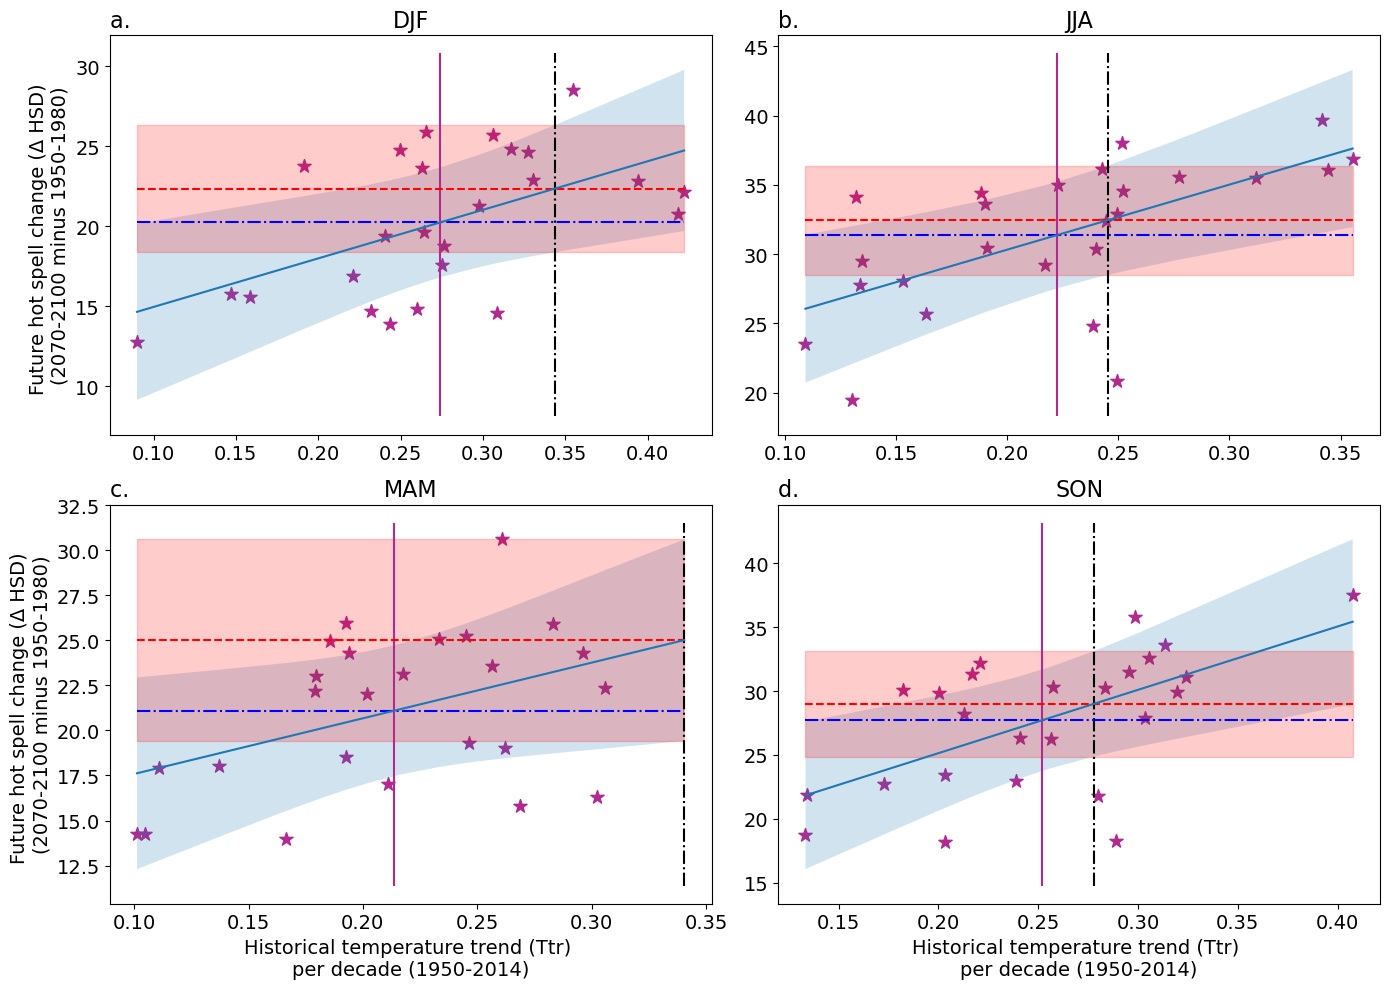

In [10]:
#plot correlation on average
fig=plt.figure(figsize=(14,10))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')

for i,season in enumerate(change_heatfut.season.values):
    
    ax=fig.add_subplot(2,2,i+1)
    xtmp_weighted=seas(tmphist_lnd,season)
    y_weighted=seas(change_heatfut,season)
    
    xtmpera_weighted=seas(trseas_tmp_era,season)
    xtmpbk_weighted=seas(trseas_tmp_bk,season)
    ax.scatter(10*xtmp_weighted,y_weighted,marker='*', s=100,c=cmap(0.4),label='CMIP6 (μ)')
    
    #ax.vlines(10*xtmpbk_weighted,0,10*y_weighted.max(),color=cmap2(0.75),linestyle='--',label='Berkeley (μ)')
    
    xtmp_weighted2=xtmp_weighted.sortby(xtmp_weighted)
    y_weighted2=y_weighted.sortby(xtmp_weighted)
    
    x=10*xtmp_weighted2.values
    y=y_weighted2.values
    
    xob=10*xtmpera_weighted
    n=len(x)
    a, b = np.polyfit(x, y, deg=1)
    y_est = a * x + b
    
    
    
    y_mmm=y_est.mean()
    x_mmm=x.mean()
    
    y_ob=a*(xob - x_mmm)+ y_mmm


    # Calculate the standard error of the estimate (manual formula)

    SE = np.sqrt((np.array(y)-y_est).var() * np.sqrt(1/len(x) + (x - x.mean())**2 / np.sum((x - x.mean())**2)))

    tc = t.ppf(0.975, n-2)
    CIupper=y_est+(tc*SE)
    CIlower=y_est-(tc*SE)
    
    SE_o=  np.sqrt((np.array(y)-y_est).var() * np.sqrt(1/len(x) + (xob - x.mean())**2 / np.sum((x - x.mean())**2)))
    CIupperob=y_ob+(tc*SE_o)
    CIlowerob=y_ob-(tc*SE_o)
    
    
    CIupper=np.append(CIupper,CIupperob)
    CIlower=np.append(CIlower,CIlowerob)
    y_est=np.append(y_est,y_ob)
    x=np.append(x,xob)
    
    indices = np.argsort(x)


    x = x[indices]
    y_est = y_est[indices]
    CIupper = CIupper[indices]
    CIlower = CIlower[indices]
    
    ax.fill_between(x, CIlower, CIupper, alpha=0.2)
    
    
    ax.fill_between(x, CIlowerob, CIupperob,color= 'red', alpha=0.2)
    
    ax.plot(x, y_est, '-', label='Linear Fit')
    
    ymin, ymax = plt.ylim()
    ax.vlines(10*xtmp_weighted.mean(),ymin,ymax,color=cmap(0.4),label='CMIP6 mmm (μ)')
    ax.vlines(10*xtmpera_weighted,ymin,ymax,color='k', linestyle='-.',label='ERA5 (μ)')
    
    ax.hlines(y_ob,x.min(),x.max(),color='red',linestyle='--',label='CMIP adjmean')
    ymm=a* x_mmm +b 
    ax.hlines(ymm,x.min(),x.max(),color='blue',linestyle='-.',label='CMIP ormean')
    
    print(ymm, y_ob)
    #ax.fill_between(x, y_est - y_err, y_est + y_err, alpha=0.2, label='Uncertainty Band')
    ax.set_title(letters[i], loc='left', fontsize=16)
    ax.set_title(season, fontsize=16)
    ax.set_ylabel('Future hot spell change (\u0394 HSD) \n(2070-2100 minus 1950-1980)', fontsize=14)
    ax.set_xlabel('Historical temperature trend (Ttr) \nper decade (1950-2014)', fontsize=14)
    
    if i%2>0:
        ax.set_ylabel('')
    if i<2:
        ax.set_xlabel('')


    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
handles=[]
labels=[]
h, l = ax.get_legend_handles_labels()
handles.extend(h)
labels.extend(l)
#fig.legend(handles, labels, loc='lower right', fontsize=14, bbox_to_anchor=(0.65, 0.1)) 
plt.tight_layout()
plt.savefig('plots_fix/ECs_tmp2014-chht_30yrs_fig4.png')


In [8]:
#compute correlations (30years future)
print ('Future 30year clims')
for i,season in enumerate(change_heatfut.season.values):
    xtmp_weighted=seas(tmphist_lnd,season)
    y_weighted=seas(change_heatfut,season)
    res = stats.pearsonr(xtmp_weighted,y_weighted)
    print(season+' Corr:',res)


Future 30year clims
DJF Corr: PearsonRResult(statistic=0.5315261745468847, pvalue=0.006250407345660333)
JJA Corr: PearsonRResult(statistic=0.6313803359143346, pvalue=0.0007125475241848704)
MAM Corr: PearsonRResult(statistic=0.4178179838798631, pvalue=0.037682640802199574)
SON Corr: PearsonRResult(statistic=0.5938949002727121, pvalue=0.0017480360758674839)


In [9]:
#compute correlations (30years hist)
print ('Historical')
for i,season in enumerate(change_heathist.season.values):
    xtmp_weighted=seas(tmphist_lnd,season)
    y_weighted=seas(change_heathist,season)
    res = stats.pearsonr(xtmp_weighted,y_weighted)
    print(season+' Corr:',res)


Historical
DJF Corr: PearsonRResult(statistic=0.7752612634348494, pvalue=5.33113542102542e-06)
JJA Corr: PearsonRResult(statistic=0.9391481872191944, pvalue=3.6982687082847985e-12)
MAM Corr: PearsonRResult(statistic=0.8129399148809934, pvalue=7.887893709828463e-07)
SON Corr: PearsonRResult(statistic=0.8817167863612257, pvalue=5.78319868150739e-09)


In [14]:
#spatial correlation (hist)
y_spat=change_heathist.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t
x_spat=tmphist_lnd.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t

slope, pval = xr.apply_ufunc(
        corsp,
        x_spat,y_spat,  # your variable (time on first axis)
        input_core_dims=[['models'], ['models']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float]
    )

In [ ]:
#plot spatial CORR HIST
fig=plt.figure(figsize=(18,5))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')
sig=xr.where(pval<0.05,1,np.nan)
# for i in range(25):
#     ax.scatter(xtmp_all.isel(models=i),10*yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=10*ylow, ymax=10*yup, color=cmap(0.8),alpha=1, linestyle='--')


# ax.scatter(xera_all,10*yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
# ax.scatter(xbk_all,10*ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')
order=[0,2,1,3]

for i,season in enumerate(change_heathist.season.values):
    
    ax=fig.add_subplot(2,2,i+1, projection=ccrs.PlateCarree())
    m_v=slope.isel(season=order[i]).plot(ax=ax, cmap='RdBu_r', vmax=1, vmin=-1, add_colorbar=False)
    ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

    
    ax.set_title(slope.isel(season=order[i]).season.values, fontsize=16)
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)
    ax.set_title(letters[i], loc='left', fontsize=16)
#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()

    if i<2:
        gl.bottom_labels = False
    if i%2>0:
        gl.left_labels = False


cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
cbl=fig.colorbar(m_v, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="Pearson's correlation",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)
#plt.tight_layout()
plt.savefig('plots_fix/ECs_spatial_historical.png')


In [18]:
#Compute corrected dat
a, b = xr.apply_ufunc(
        linereg,
        x_spat,y_spat,  # your variable (time on first axis)
        input_core_dims=[['models'], ['models']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float]
    )

ht_erabased=a*(trseas_tmp_era - x_spat.mean(dim='models')) + y_spat.mean(dim='models')

In [20]:
#Actual era5 heat changes (hist)
era_heat=xr.open_dataset('../timing/era5/era5_tasmean_heat_days_1950-2024_fixednew.nc')
eraht_midl2=cutmidlat(era_heat)
eraht_lnd2=landmask(eraht_midl2)

eraht_lndclim=eraht_lnd2.heatdays.groupby("time.year").map(
        lambda x: x.groupby("time.season").sum("time")
    )

change_heat_era=eraht_lndclim.sel(year=slice(1984,2014)).mean(dim='year') - eraht_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 


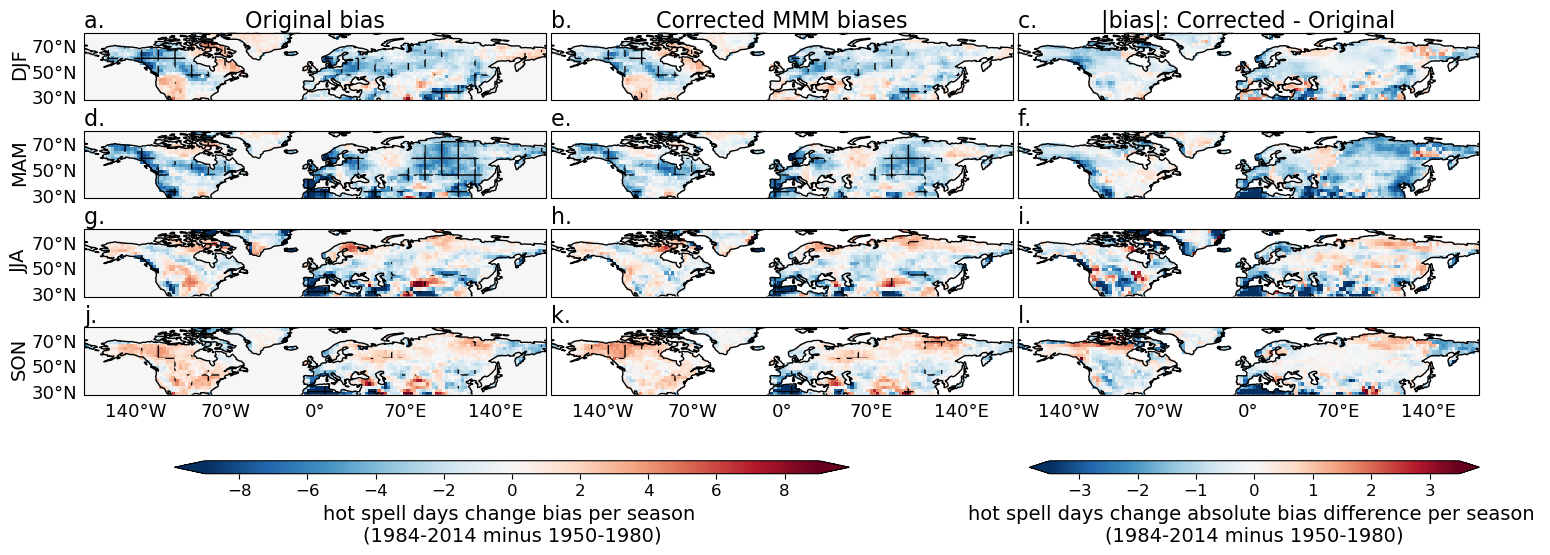

In [31]:
#plot final
titles=change_heat_era.season.values
#map_plotter(dats,2,2,4,titles,cmap='Reds',vmax=0.05,height=5)

fig=plt.figure(figsize=(18,6.5))
numplots=np.arange(1,5)
gs = fig.add_gridspec(5,4)
# difs_hist=[]
order=np.array([0,2,1,3])
for i in range (4):
    ax=fig.add_subplot(4,3,3*numplots[i]-2,projection=ccrs.PlateCarree())
        
     
    dif1=change_heathist.isel(season=order[i]).mean(dim='models') - change_heat_era.isel(season=order[i])
#     pval=xr.where(pvs>0.8,trseas_mn_era.isel(season=order[i]),np.nan) 
    m1=(dif1).plot(ax=ax, vmax=9,vmin=-9,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(era_hatch_tr.longitude,era_hatch_tr.latitude, era_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    #gl.left_labels = False
    
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.96)
    ax.text(-0.12, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
 
    ax.coastlines()
    if i==0:
        ax.set_title('Original bias', fontsize=16, y=0.96)
    else:
        ax.set_title('')
    
    if i<3:
        gl.bottom_labels = False
           
        
    ax=fig.add_subplot(4,3,3*numplots[i]-1,projection=ccrs.PlateCarree())

    dif2=ht_erabased.isel(season=order[i]) - change_heat_era.isel(season=order[i])

    m=(dif2).plot(ax=ax, cmap='RdBu_r', vmin=-9,vmax=9,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(era_hatch_tr_con.longitude,era_hatch_tr_con.latitude, era_hatch_tr_con.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.96)
    
    if i==0:
        ax.set_title('Corrected MMM biases', fontsize=16,y=0.96)
    else:
        ax.set_title('')
    
    if i<3:
        gl.bottom_labels = False

    ax=fig.add_subplot(4,3,3*numplots[i],projection=ccrs.PlateCarree())
        
    dif3=abs(dif2) - abs(dif1)
    
#     pers=100*(dif3/abs(dif1))
    
#     difs_hist.append(dif3)
    
    m2=(dif3).plot(ax=ax, cmap='RdBu_r', vmin=-3.5,vmax=3.5,transform=ccrs.PlateCarree(),add_colorbar=False)
    #ax.contourf(era_hatch_tr_con.longitude,era_hatch_tr_con.latitude, era_hatch_tr_con.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    if i==0:
        ax.set_title('|bias|: Corrected - Original', fontsize=16,y=0.96)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.96)
        
#     if i<3:
#         ax.set_xticks([])
#     else:
#         ax.set_xlabel("hot spell days trend per decade",fontsize=14)
#     if i==3:
#         plt.legend(loc='lower left', ncol=2, bbox_to_anchor=(-0.18, -1.7),columnspacing=0.5, fontsize=14)
    
#     if i==2 or i==3:

#         ax.set_ylabel(' ')
#     elif i==3:
#         plt.legend()
#     if i%2>0:
#         gl.left_labels = False
        
cbar_ax = fig.add_axes([0.175, 0.18, 0.375, 0.02])
cbl=fig.colorbar(m1, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="hot spell days change bias per season \n(1984-2014 minus 1950-1980)",size=14)
cbl.ax.tick_params(labelsize=12)

cbar_ax = fig.add_axes([0.65, 0.18, 0.25, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="hot spell days change absolute bias difference per season \n(1984-2014 minus 1950-1980)",size=14)
cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.03, wspace=0.01, bottom=0.28)

# plt.tight_layout()
plt.savefig('Plots/hotspell_changes_corrected_hist.png')
plt.show()

In [24]:
#spatial corr future changes
#change_heat=htfut_lndclim.sel(year=slice(2070,2100)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 

y_spat=change_heatfut.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t
x_spat=tmphist_lnd.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t

slopeT, pvalT = xr.apply_ufunc(
        corsp,
        x_spat,y_spat,  # your variable (time on first axis)
        input_core_dims=[['models'], ['models']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float]
    )

In [26]:
#plot spatial CORR FUT
fig=plt.figure(figsize=(18,5))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')
sig=xr.where(pval<0.05,1,np.nan)
# for i in range(25):
#     ax.scatter(xtmp_all.isel(models=i),10*yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=10*ylow, ymax=10*yup, color=cmap(0.8),alpha=1, linestyle='--')


# ax.scatter(xera_all,10*yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
# ax.scatter(xbk_all,10*ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')
order=[0,2,1,3]

for i,season in enumerate(change_heatfut.season.values):
    
    ax=fig.add_subplot(2,2,i+1, projection=ccrs.PlateCarree())
    m_v=slope.isel(season=order[i]).plot(ax=ax, cmap='RdBu_r', vmax=1, vmin=-1, add_colorbar=False)
    ax.contourf(pval.longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

    
    ax.set_title(slope.isel(season=order[i]).season.values, fontsize=16)
    ax.set_title(letters[i], loc='left', fontsize=16)
#ax.axhline(color='k', linestyle='--')
#ax.axvline(color='k', linestyle='--')
#ax.set_title(letters[0],loc='left',fontsize=16)

#ax.set_xticks(np.arange(0,0.9,0.3))
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.ylocator = mticker.FixedLocator([ 30,50,70])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()

    if i<2:
        gl.bottom_labels = False
    if i%2>0:
        gl.left_labels = False


cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
cbl=fig.colorbar(m_v, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="Pearson's correlation",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)
#plt.tight_layout()
plt.savefig('plots_fix/ECs_spatial_temp_future.png')


In [27]:
#corrected future
a, b = xr.apply_ufunc(
        linereg,
        x_spat,y_spat,  # your variable (time on first axis)
        input_core_dims=[['models'], ['models']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float]
    )


ht_erabased=a*(trseas_tmp_era - x_spat.mean(dim='models')) + y_spat.mean(dim='models')

In [29]:
#latvar corrected

trseasfut_heat=change_heatfut.copy(deep=True)
trend_annual_mnfut2=trseasfut_heat.mean(dim='season')

trend_dif_cmipfut=((trseasfut_heat-trend_annual_mnfut2).mean(dim='longitude'))
trend_dif_cmipfut_mean=trend_dif_cmipfut.mean(dim='models')

#
trseasfut_heatcon=ht_erabased.copy(deep=True)
trend_annual_mnfutcon2=trseasfut_heatcon.mean(dim='season')

trend_dif_cmipfut_con=((trseasfut_heatcon-trend_annual_mnfutcon2).mean(dim='longitude'))

trend_dif_cmip_upper=trend_dif_cmipfut.quantile(0.975,dim='models')
trend_dif_cmip_lower=trend_dif_cmipfut.quantile(0.025,dim='models')


trend_dif_cmip_upper2=trend_dif_cmip_upper+(trseasfut_heatcon-trseasfut_heat.mean(dim='models')).mean(dim='longitude')
trend_dif_cmip_lower2=trend_dif_cmip_lower+(trseasfut_heatcon-trseasfut_heat.mean(dim='models')).mean(dim='longitude')

# trend_dif_cmipfut_upper=trend_dif_cmipfut.quantile(0.975,dim='models')
# trend_dif_cmipfut_lower=trend_dif_cmipfut.quantile(0.025,dim='models')

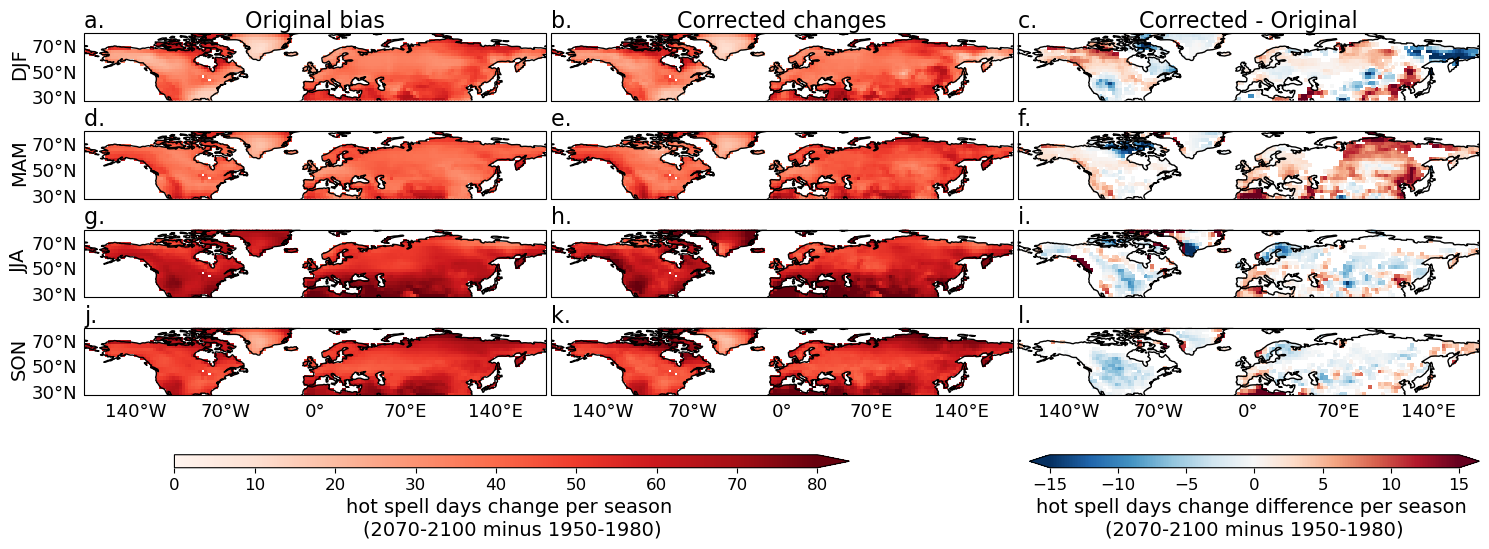

In [30]:
#plot future
titles=trend_dif_cmipfut_con.season.values
#map_plotter(dats,2,2,4,titles,cmap='Reds',vmax=0.05,height=5)

fig=plt.figure(figsize=(18,6.5))
numplots=np.arange(1,5)
gs = fig.add_gridspec(5,4)

order=np.array([0,2,1,3])
for i in range (4):
    ax=fig.add_subplot(4,3,3*numplots[i]-2,projection=ccrs.PlateCarree())
        
     
    dif1=landmask(change_heatfut.isel(season=order[i]).mean(dim='models'))# - change_heat_era.isel(season=order[i])
#     pval=xr.where(pvs>0.8,trseas_mn_era.isel(season=order[i]),np.nan) 
    m1=(dif1).plot(ax=ax, vmax=80,vmin=0,cmap='Reds',transform=ccrs.PlateCarree(),add_colorbar=False)
    #ax.contourf(era_hatch_tr.longitude,era_hatch_tr.latitude, era_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    #gl.left_labels = False
    
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.96)
    ax.text(-0.12, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
 
    ax.coastlines()
    if i==0:
        ax.set_title('Original bias', fontsize=16, y=0.96)
    else:
        ax.set_title('')
    
    if i<3:
        gl.bottom_labels = False
           
        
    ax=fig.add_subplot(4,3,3*numplots[i]-1,projection=ccrs.PlateCarree())

    dif2=ht_erabased.isel(season=order[i]) #- change_heat_era.isel(season=order[i])

    m=(dif2).plot(ax=ax, cmap='Reds', vmin=0,vmax=80,transform=ccrs.PlateCarree(),add_colorbar=False)
    #ax.contourf(era_hatch_tr_con.longitude,era_hatch_tr_con.latitude, era_hatch_tr_con.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.96)
    
    if i==0:
        ax.set_title('Corrected changes', fontsize=16,y=0.96)
    else:
        ax.set_title('')
    
    if i<3:
        gl.bottom_labels = False

    ax=fig.add_subplot(4,3,3*numplots[i],projection=ccrs.PlateCarree())
        
    dif3=dif2 - dif1
    dif4=dif3.where(difs_hist[i]<0)
    m2=(dif4).plot(ax=ax, cmap='RdBu_r', vmin=-15,vmax=15,transform=ccrs.PlateCarree(),add_colorbar=False)
    #ax.contourf(era_hatch_tr_con.longitude,era_hatch_tr_con.latitude, era_hatch_tr_con.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    if i==0:
        ax.set_title('Corrected - Original', fontsize=16,y=0.96)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.96)
        
#     if i<3:
#         ax.set_xticks([])
#     else:
#         ax.set_xlabel("hot spell days trend per decade",fontsize=14)
#     if i==3:
#         plt.legend(loc='lower left', ncol=2, bbox_to_anchor=(-0.18, -1.7),columnspacing=0.5, fontsize=14)
    
#     if i==2 or i==3:

#         ax.set_ylabel(' ')
#     elif i==3:
#         plt.legend()
#     if i%2>0:
#         gl.left_labels = False
        
cbar_ax = fig.add_axes([0.175, 0.19, 0.375, 0.02])
cbl=fig.colorbar(m1, cax=cbar_ax, extend='max',orientation='horizontal')
cbl.set_label(label="hot spell days change per season \n(2070-2100 minus 1950-1980)",size=14)
cbl.ax.tick_params(labelsize=12)

cbar_ax = fig.add_axes([0.65, 0.19, 0.25, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="hot spell days change difference per season \n(2070-2100 minus 1950-1980)",size=14)
cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.03, wspace=0.01, bottom=0.28)

# plt.tight_layout()
plt.savefig('plots_fix/hotspell_changes_corrected_fut_fig8.png')
plt.show()

## Fluxes

In [31]:
#model names
models_alb=np.array(['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'E3SM-1-1', 'FGOALS-g3', 'IITM-ESM',  'MIROC6', 'MPI-ESM1-2-LR', 'NESM3', 'NorESM2-MM'])
models_albsh=models_alb[np.isin(models_alb,models)]

models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM','CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models_hfls=np.array(models1+models22)
models_hflssh=models_hfls[np.isin(models_hfls,models)]

models1=['ACCESS-CM2','AWI-CM-1-1-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models_hfss=np.array(models1+models22)
models_hfsssh=models_hfss[np.isin(models_hfss,models)]

mnames1=[models_albsh,models_albsh,models_hflssh,models_hfsssh]
mnames2=[models_alb,models_alb,models_hfls,models_hfss]


In [54]:
#read flux trends
fluxes=['rsus','rsds','hfls','hfss']
dflx=[]
for i,d in enumerate(fluxes):
    trseas_hist=xr.open_dataset('mk_trends_'+d+'2014_cmip.nc')
    trseas_hist=(trseas_hist.rename({'model':'models'})[d].assign_coords(models=mnames2[i]))#.rename({'model','models'})
    hist_midl=cutmidlat(trseas_hist)
    hist_lnd=landmask(hist_midl)
    dflx.append(hist_lnd)


#pvseas_heatfut=xr.open_dataset('../timing/cmip6_heat_fut_mkpvals.nc').tas

In [ ]:
#plot correlation on average
fig=plt.figure(figsize=(14,10))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')

fig.text(-3.85, 2.5, 'Future hot spell change (\u0394 HSD)(2030-2099 minus 1950-2024)', fontsize=14, rotation='vertical', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

order=np.array([0,2,1,3])
ss=change_heat.season.values
ss2=np.array([ss[0],ss[2],ss[1],ss[3]])
for i,season in enumerate(ss2):
    for j,d in enumerate(dflx):
        num=(4*(i+1)+(j+1) -4)
        ax=fig.add_subplot(4,4,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heat,season).sel(models=mnames1[j]).sortby(x_weighted.models)

#         xera_weighted=seas(trseas_tmp_era,season)
#         xbk_weighted=seas(trseas_tmp_bk,season)
        ax.scatter(10*x_weighted,y_weighted,marker='*', s=100,c=cmap(0.4),label='CMIP6 (μ)')

        #ax.vlines(10*xbk_weighted,0,10*y_weighted.max(),color=cmap2(0.75),linestyle='--',label='Berkeley (μ)')

        x_weighted2=x_weighted.sortby(x_weighted)
        y_weighted2=y_weighted.sortby(x_weighted)

        x=10*x_weighted2.values
        y=y_weighted2.values

        #xob=10*xera_weighted
        n=len(x)
        a, b = np.polyfit(x, y, deg=1)
        y_est = a * x + b



        y_mmm=y_est.mean()
        x_mmm=x.mean()


        SE = np.sqrt((np.array(y)-y_est).var() * np.sqrt(1/len(x) + (x - x.mean())**2 / np.sum((x - x.mean())**2)))

        tc = t.ppf(0.975, n-2)
        CIupper=y_est+(tc*SE)
        CIlower=y_est-(tc*SE)


        ax.fill_between(x, CIlower, CIupper, alpha=0.2)


        #ax.fill_between(x, CIlowerob, CIupperob,color= 'red', alpha=0.2)

        ax.plot(x, y_est, '-', label='Linear Fit')

        ymin, ymax = plt.ylim()
        ax.vlines(10*x_weighted.mean(),ymin,ymax,color=cmap(0.4),label='CMIP6 mmm (μ)')
        #ax.vlines(10*xera_weighted,ymin,ymax,color='k', linestyle='-.',label='ERA5 (μ)')

        #ax.hlines(y_ob,x.min(),x.max(),color='red',linestyle='--',label='CMIP adjmean')

        #ax.fill_between(x, y_est - y_err, y_est + y_err, alpha=0.2, label='Uncertainty Band')
        ax.set_title(letters[num-1], loc='left', fontsize=16)
        if i==0:
            ax.set_title(fluxes[j], fontsize=16)
        ax.set_ylabel(season, fontsize=14)
        #ax.set_ylabel('Future hot spell change (\u0394 HSD) \n(2030-2099 minus 1950-2024)', fontsize=14)
        ax.set_xlabel('Historical '+fluxes[j]+' trend \nper decade (1950-2014)', fontsize=14)

        if j%4>0:
            ax.set_ylabel('')
        if i<3:
            ax.set_xlabel('')


        plt.yticks(fontsize=14)
        plt.xticks(fontsize=14)
#     handles=[]
#     labels=[]
#     h, l = ax.get_legend_handles_labels()
#     handles.extend(h)
#     labels.extend(l)
    #fig.legend(handles, labels, loc='lower right', fontsize=14, bbox_to_anchor=(0.65, 0.1)) 
plt.tight_layout()
plt.subplots_adjust(left=0.1)
#fig.supylabel('Future hot spell change (\u0394 HSD) \n(2030-2099 minus 1950-2024)', fontsize=14)
plt.savefig('Plots/ECs_fluxes2014-chht_30yrs.png')


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

In [59]:
#correlation values
from scipy import stats
print ('Historical')
varsout=[]

for j,d in enumerate(dflx):
    eachcors=[]
    order=[0,2,1,3]
    for i in range(len(change_heathist.season.values)):
        num=(4*(i+1)+(j+1) -4)
        ax=fig.add_subplot(4,4,num)
        season=change_heathist.season.values[order[i]]
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heathist,season).sel(models=mnames1[j]).sortby(x_weighted.models)
    
        res = stats.pearsonr(x_weighted,y_weighted)
        #if res[-1]<0.1 or res[0]>0.3:
        print(fluxes[j],season+' Corr:',res)
        if res[-1]<0.05:
            eachcors.append( str(round(res[0], 2))+'*')
        elif res[-1]<0.01:
            eachcors.append( str(round(res[0], 2))+'**')
        elif res[-1]<0.001:
            eachcors.append( str(round(res[0], 2))+'***')
        else:
            eachcors.append( str(round(res[0], 2)))
    varsout.append(eachcors)

Historical
rsus DJF Corr: PearsonRResult(statistic=-0.6136629193392957, pvalue=0.019584682344627794)
rsus MAM Corr: PearsonRResult(statistic=-0.6115976179907527, pvalue=0.020116525836066556)
rsus JJA Corr: PearsonRResult(statistic=-0.09469776816610062, pvalue=0.7474406477592641)
rsus SON Corr: PearsonRResult(statistic=-0.44373433883298474, pvalue=0.11198063139390647)
rsds DJF Corr: PearsonRResult(statistic=-0.326227516139116, pvalue=0.2549867335077926)
rsds MAM Corr: PearsonRResult(statistic=-0.21434435273160435, pvalue=0.4618227537048376)
rsds JJA Corr: PearsonRResult(statistic=0.5289765091875857, pvalue=0.051779551050793154)


/tmp/99589.admin.default.domain/ipykernel_101751/660991744.py:10: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax=fig.add_subplot(4,4,num)
/tmp/99589.admin.default.domain/ipykernel_101751/660991744.py:10: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax=fig.add_subplot(4,4,num)
/tmp/99589.admin.default.domain/ipykernel_101751/660991744.py:10: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous ax

rsds SON Corr: PearsonRResult(statistic=0.021617392467935342, pvalue=0.9415265951467977)
hfls DJF Corr: PearsonRResult(statistic=0.0870593380220396, pvalue=0.7000585529113601)
hfls MAM Corr: PearsonRResult(statistic=0.17262982933968524, pvalue=0.44234668145939254)
hfls JJA Corr: PearsonRResult(statistic=0.3466016861740168, pvalue=0.11404943521980906)
hfls SON Corr: PearsonRResult(statistic=0.10493112364520672, pvalue=0.642126131342289)
hfss DJF Corr: PearsonRResult(statistic=0.06712506938242468, pvalue=0.7608906240442033)
hfss MAM Corr: PearsonRResult(statistic=0.05469750360120294, pvalue=0.8042299043099191)
hfss JJA Corr: PearsonRResult(statistic=-0.12168406561707465, pvalue=0.5801986775535226)


/tmp/99589.admin.default.domain/ipykernel_101751/660991744.py:10: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax=fig.add_subplot(4,4,num)
/tmp/99589.admin.default.domain/ipykernel_101751/660991744.py:10: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax=fig.add_subplot(4,4,num)
/tmp/99589.admin.default.domain/ipykernel_101751/660991744.py:10: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous ax

hfss SON Corr: PearsonRResult(statistic=-0.1885952117531302, pvalue=0.3887956147141246)


In [62]:
#correlation against historical hot spell changes
from scipy import stats
print ('Historical')
for j,d in enumerate(dflx):
    for i,season in enumerate(change_heathist.season.values):
        num=(4*(i+1)+(j+1) -4)
        ax=fig.add_subplot(4,4,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heathist,season).sel(models=mnames1[j]).sortby(x_weighted.models)
    
        res = stats.pearsonr(x_weighted,y_weighted)
        #if res[-1]<0.1 or res[0]>0.3:
        print(fluxes[j],season+' Corr:',res)


Historical
rsus DJF Corr: PearsonRResult(statistic=-0.6136629193392957, pvalue=0.019584682344627794)
rsus JJA Corr: PearsonRResult(statistic=-0.09469776816610062, pvalue=0.7474406477592641)
rsus MAM Corr: PearsonRResult(statistic=-0.6115976179907527, pvalue=0.020116525836066556)
rsus SON Corr: PearsonRResult(statistic=-0.44373433883298474, pvalue=0.11198063139390647)
rsds DJF Corr: PearsonRResult(statistic=-0.326227516139116, pvalue=0.2549867335077926)
rsds JJA Corr: PearsonRResult(statistic=0.5289765091875857, pvalue=0.051779551050793154)
rsds MAM Corr: PearsonRResult(statistic=-0.21434435273160435, pvalue=0.4618227537048376)


/tmp/99589.admin.default.domain/ipykernel_101751/3401281900.py:6: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax=fig.add_subplot(4,4,num)
/tmp/99589.admin.default.domain/ipykernel_101751/3401281900.py:6: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax=fig.add_subplot(4,4,num)
/tmp/99589.admin.default.domain/ipykernel_101751/3401281900.py:6: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous ax

rsds SON Corr: PearsonRResult(statistic=0.021617392467935342, pvalue=0.9415265951467977)
hfls DJF Corr: PearsonRResult(statistic=0.0870593380220396, pvalue=0.7000585529113601)
hfls JJA Corr: PearsonRResult(statistic=0.3466016861740168, pvalue=0.11404943521980906)
hfls MAM Corr: PearsonRResult(statistic=0.17262982933968524, pvalue=0.44234668145939254)
hfls SON Corr: PearsonRResult(statistic=0.10493112364520672, pvalue=0.642126131342289)
hfss DJF Corr: PearsonRResult(statistic=0.06712506938242468, pvalue=0.7608906240442033)
hfss JJA Corr: PearsonRResult(statistic=-0.12168406561707465, pvalue=0.5801986775535226)
hfss MAM Corr: PearsonRResult(statistic=0.05469750360120294, pvalue=0.8042299043099191)


/tmp/99589.admin.default.domain/ipykernel_101751/3401281900.py:6: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax=fig.add_subplot(4,4,num)
/tmp/99589.admin.default.domain/ipykernel_101751/3401281900.py:6: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax=fig.add_subplot(4,4,num)
/tmp/99589.admin.default.domain/ipykernel_101751/3401281900.py:6: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous ax

hfss SON Corr: PearsonRResult(statistic=-0.1885952117531302, pvalue=0.3887956147141246)


In [65]:
#spatial corr agst future changes
dslopes=[]
dpvals=[]
for j,d in enumerate(dflx):
    xx=d.sel(models=mnames1[j])
    yy=change_heatfut.sel(models=mnames1[j]).sortby(xx.models)
    y_spat=yy.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t
    x_spat=xx.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t
    y_spat['models']=x_spat.models
    slope, pval = xr.apply_ufunc(
            corsp,
            x_spat,y_spat,  # your variable (time on first axis)
            input_core_dims=[['models'], ['models']],
            output_core_dims=[[], []],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float, float]
        )
    dslopes.append(slope)
    dpvals.append(pval)

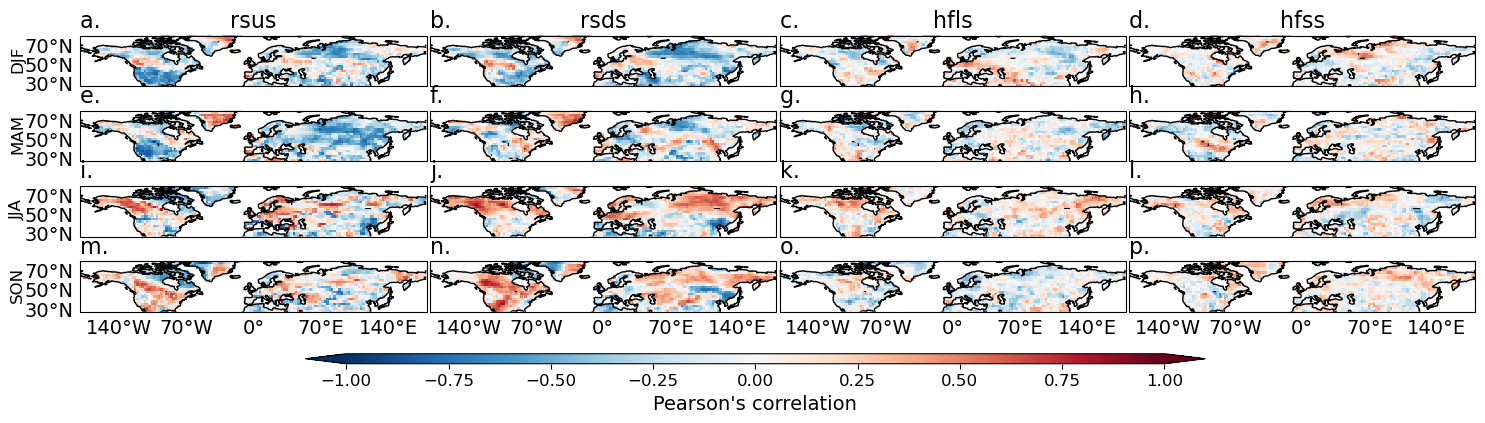

In [68]:
#plot spatial CORR FUT
fig=plt.figure(figsize=(18,5))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')
sig=xr.where(pval<0.05,1,np.nan)
# for i in range(25):
#     ax.scatter(xtmp_all.isel(models=i),10*yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=10*ylow, ymax=10*yup, color=cmap(0.8),alpha=1, linestyle='--')


# ax.scatter(xera_all,10*yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
# ax.scatter(xbk_all,10*ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')
order=[0,2,1,3]
for i,season in enumerate(slope.season.values):
    for j,d in enumerate(dflx):
        num=(4*(i+1)+(j+1) -4)
        ax=fig.add_subplot(4,4,num, projection=ccrs.PlateCarree())

        m_v=dslopes[j].isel(season=order[i]).plot(ax=ax, cmap='RdBu_r', vmax=1, vmin=-1, add_colorbar=False)
        ax.contourf(dpvals[j].longitude,pval.latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

        if i<1:
            ax.set_title(fluxes[j], fontsize=16)
        else:
            ax.set_title('')
        ax.set_title(letters[num-1], loc='left', fontsize=16)
    #ax.axhline(color='k', linestyle='--')
    #ax.axvline(color='k', linestyle='--')
    #ax.set_title(letters[0],loc='left',fontsize=16)
        if j==0:
            ax.text(-0.16, 0.55, dslopes[j].season.values[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=12)


    #ax.set_xticks(np.arange(0,0.9,0.3))
        gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")

        gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
        gl.ylocator = mticker.FixedLocator([ 30,50,70])
        gl.top_labels = False
        gl.right_labels = False
        #gl.ylabels_rit2mt = False

        gl.xlabel_style = {'size': 14}
        gl.ylabel_style = {'size': 14}
        ax.coastlines()

        if i<3:
            gl.bottom_labels = False
        if j%4>0:
            gl.left_labels = False


cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
cbl=fig.colorbar(m_v, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="Pearson's correlation",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)
#plt.tight_layout()
plt.savefig('plots_fix/ECs_fluxes_spatial_future.png')


## State vars

In [69]:
#model names
models_alb=np.array(['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'E3SM-1-1', 'FGOALS-g3', 'IITM-ESM',  'MIROC6', 'MPI-ESM1-2-LR', 'NESM3', 'NorESM2-MM'])
models_albsh=models_alb[np.isin(models_alb,models)]

models_snow=np.array([ 'BCC-CSM2-MR', 'CanESM5', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'EC-Earth3-CC', 'EC-Earth3-Veg-LR', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'KIOST-ESM', 'MIROC6','MRI-ESM2-0', 'NorESM2-MM', 'TaiESM1'])
models_snowsh=models_snow[np.isin(models_snow,models)]

models_mrso=np.array(['BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2-WACCM','CESM2','CMCC-CM2-SR5','CMCC-ESM2','CNRM-CM6-1-HR','E3SM-1-1','EC-Earth3-CC','EC-Earth3-Veg-LR', 'MIROC6',  'MIROC-ES2L', 'MPI-ESM1-2-LR','MRI-ESM2-0','NorESM2-LM','NorESM2-MM','TaiESM1'])
models_mrsosh=models_mrso[np.isin(models_mrso,models)]

mnames1=[models_albsh,models_snowsh,models_mrsosh]
mnames2=[models_alb,models_snow,models_mrso]


In [71]:
#read var trends
states=['albedo','snowdepth','soilmoisture']
varnames=['__xarray_dataarray_variable__','snd','mrsos']
dsta=[]
for i,d in enumerate(states):
    trseas_hist=xr.open_dataset('mk_trends2014_'+d+'_cmip.nc')
    trseas_hist=(trseas_hist.rename({'model':'models'})[varnames[i]].assign_coords(models=mnames2[i]))#.rename({'model','models'})
    hist_midl=cutmidlat(trseas_hist)
    hist_lnd=landmask(hist_midl)
    dsta.append(hist_lnd)


#pvseas_heatfut=xr.open_dataset('../timing/cmip6_heat_fut_mkpvals.nc').tas

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

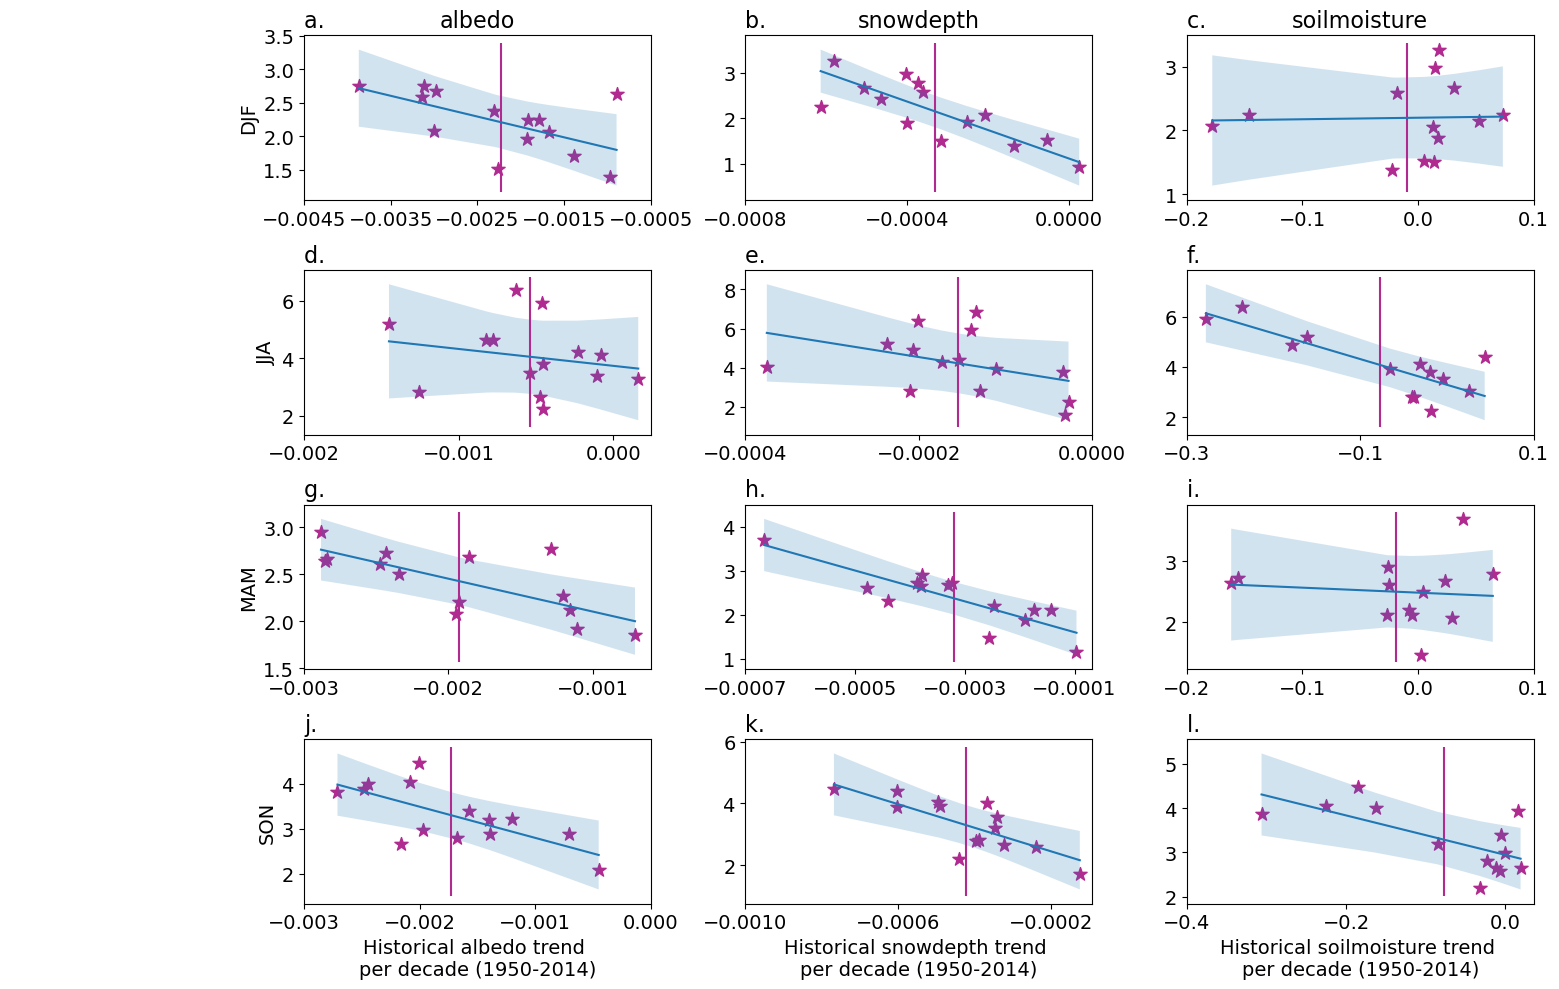

In [71]:
#plot correlation on average
fig=plt.figure(figsize=(14,10))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')

fig.text(-2.82, 2.8, 'Future hot spell change (\u0394 HSD)(2030-2099 minus 1950-2024)', fontsize=14, rotation='vertical', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)


for i,season in enumerate(change_heat.season.values):
    for j,d in enumerate(dsta):
        num=(3*(i+1)+(j+1) -3)
        ax=fig.add_subplot(4,3,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heat,season).sel(models=mnames1[j]).sortby(x_weighted.models)

#         xera_weighted=seas(trseas_tmp_era,season)
#         xbk_weighted=seas(trseas_tmp_bk,season)
        ax.scatter(10*x_weighted,y_weighted,marker='*', s=100,c=cmap(0.4),label='CMIP6 (μ)')

        #ax.vlines(10*xbk_weighted,0,10*y_weighted.max(),color=cmap2(0.75),linestyle='--',label='Berkeley (μ)')

        x_weighted2=x_weighted.sortby(x_weighted)
        y_weighted2=y_weighted.sortby(x_weighted)

        x=10*x_weighted2.values
        y=y_weighted2.values

        #xob=10*xera_weighted
        n=len(x)
        a, b = np.polyfit(x, y, deg=1)
        y_est = a * x + b



        y_mmm=y_est.mean()
        x_mmm=x.mean()

        #y_ob=a*(xob - x_mmm)+ y_mmm


        # Calculate the standard error of the estimate (manual formula)

        SE = np.sqrt((np.array(y)-y_est).var() * np.sqrt(1/len(x) + (x - x.mean())**2 / np.sum((x - x.mean())**2)))

        tc = t.ppf(0.975, n-2)
        CIupper=y_est+(tc*SE)
        CIlower=y_est-(tc*SE)


        ax.fill_between(x, CIlower, CIupper, alpha=0.2)


        #ax.fill_between(x, CIlowerob, CIupperob,color= 'red', alpha=0.2)

        ax.plot(x, y_est, '-', label='Linear Fit')

        ymin, ymax = plt.ylim()
        ax.vlines(10*x_weighted.mean(),ymin,ymax,color=cmap(0.4),label='CMIP6 mmm (μ)')
        #ax.vlines(10*xera_weighted,ymin,ymax,color='k', linestyle='-.',label='ERA5 (μ)')

        #ax.hlines(y_ob,x.min(),x.max(),color='red',linestyle='--',label='CMIP adjmean')

        #ax.fill_between(x, y_est - y_err, y_est + y_err, alpha=0.2, label='Uncertainty Band')
        ax.set_title(letters[num-1], loc='left', fontsize=16)
        ticks = ax.get_xticks()
        ax.set_xticks(ticks[::2])
        if i==0:
            ax.set_title(states[j], fontsize=16)
        ax.set_ylabel(season, fontsize=14)
        #ax.set_ylabel('Future hot spell change (\u0394 HSD) \n(2030-2099 minus 1950-2024)', fontsize=14)
        ax.set_xlabel('Historical '+states[j]+' trend \nper decade (1950-2014)', fontsize=14)

        if j%4>0:
            ax.set_ylabel('')
        if i<3:
            ax.set_xlabel('')


        plt.yticks(fontsize=14)
        plt.xticks(fontsize=14)
#     handles=[]
#     labels=[]
#     h, l = ax.get_legend_handles_labels()
#     handles.extend(h)
#     labels.extend(l)
    #fig.legend(handles, labels, loc='lower right', fontsize=14, bbox_to_anchor=(0.65, 0.1)) 
plt.tight_layout()
plt.subplots_adjust(left=0.1)
#fig.supylabel('Future hot spell change (\u0394 HSD) \n(2030-2099 minus 1950-2024)', fontsize=14)
plt.savefig('Plots/ECs_states2014-chht_30yrs.png')


In [72]:
#cor values
#change_heat=htfut_lndclim.sel(year=slice(1984,2014)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 

from scipy import stats
print ('Historical')
for j,d in enumerate(dsta):
    for i,season in enumerate(change_heathist.season.values):
#         num=(4*(i+1)+(j+1) -4)
#         ax=fig.add_subplot(4,4,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heathist,season).sel(models=mnames1[j]).sortby(x_weighted.models)
    
        res = stats.pearsonr(x_weighted,y_weighted)
        #if res[-1]<0.1 or res[0]>0.3:
        print(states[j],season+' Corr:',res)


Historical
albedo DJF Corr: PearsonRResult(statistic=-0.6052700412563667, pvalue=0.02181404657761891)
albedo JJA Corr: PearsonRResult(statistic=-0.2547146640059035, pvalue=0.37949651575127696)
albedo MAM Corr: PearsonRResult(statistic=-0.7439844073478946, pvalue=0.0022810016154971454)
albedo SON Corr: PearsonRResult(statistic=-0.694094471731211, pvalue=0.005888077382335653)
snowdepth DJF Corr: PearsonRResult(statistic=-0.791184596221814, pvalue=0.0007505415637781853)
snowdepth JJA Corr: PearsonRResult(statistic=-0.3863710559807015, pvalue=0.17238260923216736)
snowdepth MAM Corr: PearsonRResult(statistic=-0.8416072587512681, pvalue=0.00016059902434864594)
snowdepth SON Corr: PearsonRResult(statistic=-0.7893540650697006, pvalue=0.0007875236868871417)
soilmoisture DJF Corr: PearsonRResult(statistic=0.11511249359370716, pvalue=0.7080527171987085)
soilmoisture JJA Corr: PearsonRResult(statistic=-0.8139575979825067, pvalue=0.0007084574275795729)
soilmoisture MAM Corr: PearsonRResult(statisti

In [74]:
#spatial corr agst future changes
def cornan(dat1,dat2):
    try:
        ss,pp=corsp(dat1,dat2)
    except:
        ss=np.nan
        pp=np.nan
    return ss,pp
dslopes=[slopeT]
dpvals=[pvalT]
for j,d in enumerate(dsta):
    xx=d.sel(models=mnames1[j])
    yy=change_heathist.sel(models=mnames1[j]).sortby(xx.models)
    y_spat=yy.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t
    x_spat=xx.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t
    y_spat['models']=x_spat.models
    slope, pval = xr.apply_ufunc(
            cornan,
            x_spat,y_spat,  # your variable (time on first axis)
            input_core_dims=[['models'], ['models']],
            output_core_dims=[[], []],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float, float]
        )
    dslopes.append(slope)
    dpvals.append(pval)

/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


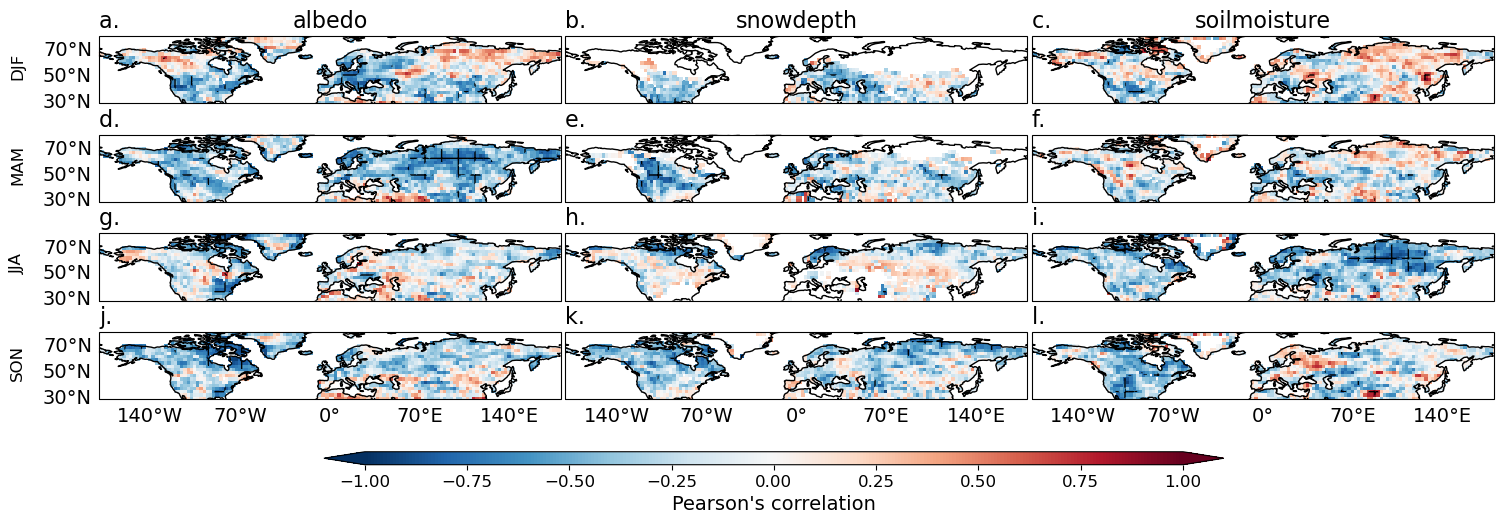

In [80]:
#plot spatial CORR hist
fig=plt.figure(figsize=(18,6.5))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')

# for i in range(25):
#     ax.scatter(xtmp_all.isel(models=i),10*yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=10*ylow, ymax=10*yup, color=cmap(0.8),alpha=1, linestyle='--')


# ax.scatter(xera_all,10*yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
# ax.scatter(xbk_all,10*ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')
order=[0,2,1,3]
for i,season in enumerate(ss2):
    for j,d in enumerate(dsta):
        num=(3*(i+1)+(j+1) -3)
        ax=fig.add_subplot(4,3,num, projection=ccrs.PlateCarree())

        m_v=dslopes[j].isel(season=order[i]).plot(ax=ax, cmap='RdBu_r', vmax=1, vmin=-1, add_colorbar=False)
        sig=xr.where(dpvals[j]<0.05,1,np.nan)
        ax.contourf(dpvals[j].longitude,dpvals[j].latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

        if i<1:
            ax.set_title(states[j], fontsize=16)
        else:
            ax.set_title('')
        ax.set_title(letters[num-1], loc='left', fontsize=16)
    #ax.axhline(color='k', linestyle='--')
    #ax.axvline(color='k', linestyle='--')
    #ax.set_title(letters[0],loc='left',fontsize=16)
        if j==0:
            ax.text(-0.16, 0.55, ss2[i], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=12)


    #ax.set_xticks(np.arange(0,0.9,0.3))
        gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")

        gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
        gl.ylocator = mticker.FixedLocator([ 30,50,70])
        gl.top_labels = False
        gl.right_labels = False
        #gl.ylabels_rit2mt = False

        gl.xlabel_style = {'size': 14}
        gl.ylabel_style = {'size': 14}
        ax.coastlines()

        if i<3:
            gl.bottom_labels = False
        if j%4>0:
            gl.left_labels = False


cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
cbl=fig.colorbar(m_v, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="Pearson's correlation",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.05, wspace=0.01, bottom=0.28)
#plt.tight_layout()
plt.savefig('Plots/ECs_states_spatial_hist.png')


In [75]:
#cor values future
#change_heat=htfut_lndclim.sel(year=slice(2070,2100)).mean(dim='year') - htfut_lndclim.sel(year=slice(1950,1980)).mean(dim='year') 

from scipy import stats
print ('Future')
for j,d in enumerate(dsta):
    for i,season in enumerate(change_heatfut.season.values):
#         num=(4*(i+1)+(j+1) -4)
#         ax=fig.add_subplot(4,4,num)
        x_weighted=seas(d,season).sel(models=mnames1[j])
        y_weighted=seas(change_heatfut,season).sel(models=mnames1[j]).sortby(x_weighted.models)
    
        res = stats.pearsonr(x_weighted,y_weighted)
        #if res[-1]<0.1 or res[0]>0.3:
        print(states[j],season+' Corr:',res)


Future
albedo DJF Corr: PearsonRResult(statistic=-0.1469015922133207, pvalue=0.6162708889095252)
albedo JJA Corr: PearsonRResult(statistic=0.03955727480901203, pvalue=0.8931959650818178)
albedo MAM Corr: PearsonRResult(statistic=-0.36835257625192064, pvalue=0.19501095743193358)
albedo SON Corr: PearsonRResult(statistic=-0.183243554165411, pvalue=0.5306224278930793)
snowdepth DJF Corr: PearsonRResult(statistic=-0.3747738386698062, pvalue=0.18674100001955213)
snowdepth JJA Corr: PearsonRResult(statistic=0.10147558452643046, pvalue=0.7299589966174476)
snowdepth MAM Corr: PearsonRResult(statistic=-0.5249664607318687, pvalue=0.053913787314661364)
snowdepth SON Corr: PearsonRResult(statistic=-0.45249174316065, pvalue=0.10425117072043466)
soilmoisture DJF Corr: PearsonRResult(statistic=-0.3461804916750312, pvalue=0.2465864519873342)
soilmoisture JJA Corr: PearsonRResult(statistic=-0.5305321013468209, pvalue=0.06214827800754826)
soilmoisture MAM Corr: PearsonRResult(statistic=-0.31562245455824

In [76]:
#spatial corr agst future changes
def cornan(dat1,dat2):
    try:
        ss,pp=corsp(dat1,dat2)
    except:
        ss=np.nan
        pp=np.nan
    return ss,pp
dslopes=[slopeT]
dpvals=[pvalT]
for j,d in enumerate(dsta):
    xx=d.sel(models=mnames1[j])
    yy=change_heatfut.sel(models=mnames1[j]).sortby(xx.models)
    y_spat=yy.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t
    x_spat=xx.to_dataset(name='t').transpose("season","latitude","longitude","models")[["season", "models","latitude","longitude","t"]].t
    y_spat['models']=x_spat.models
    slope, pval = xr.apply_ufunc(
            cornan,
            x_spat,y_spat,  # your variable (time on first axis)
            input_core_dims=[['models'], ['models']],
            output_core_dims=[[], []],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float, float]
        )
    dslopes.append(slope)
    dpvals.append(pval)

/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


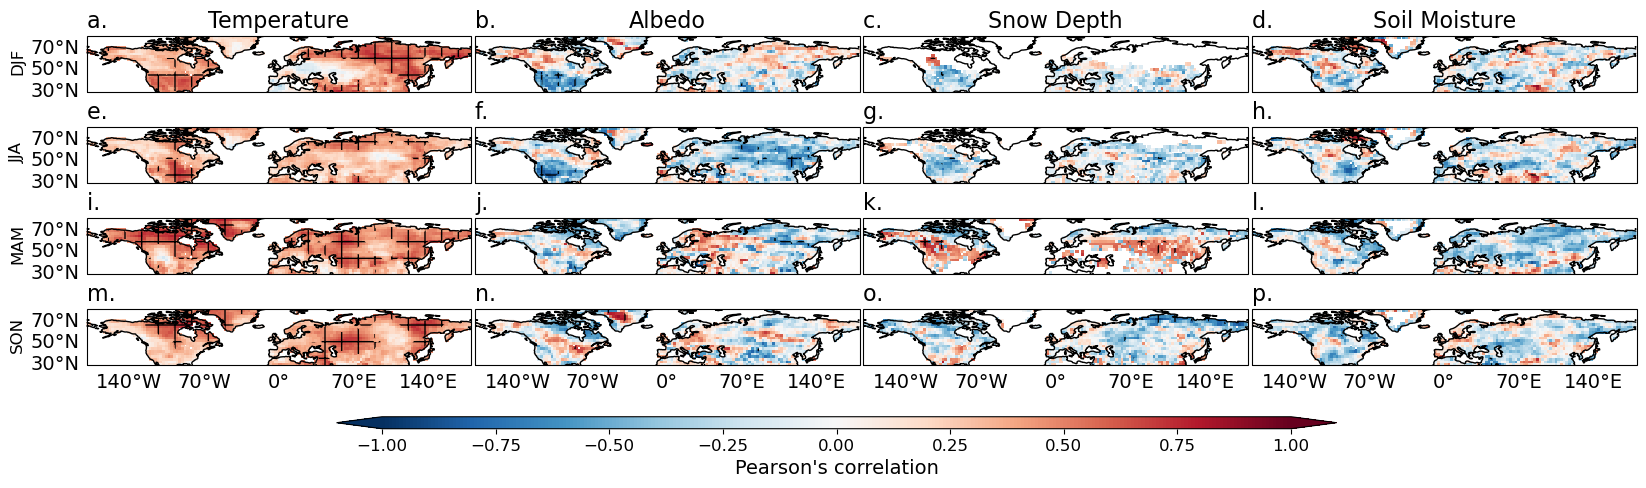

In [77]:
#plot spatial CORR FUT with temperature
fig=plt.figure(figsize=(20,6))
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')

# for i in range(25):
#     ax.scatter(xtmp_all.isel(models=i),10*yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=10*ylow, ymax=10*yup, color=cmap(0.8),alpha=1, linestyle='--')


# ax.scatter(xera_all,10*yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
# ax.scatter(xbk_all,10*ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')
states=['Temperature','Albedo','Snow Depth','Soil Moisture']
order=[0,2,1,3]
ss2=dslopes[j].season.values
for i,season in enumerate(ss2):
    for j,d in enumerate(dslopes):
        num=(4*(i+1)+(j+1) -4)
        ax=fig.add_subplot(4,4,num, projection=ccrs.PlateCarree())

        m_v=dslopes[j].isel(season=order[i]).plot(ax=ax, cmap='RdBu_r', vmax=1, vmin=-1, add_colorbar=False)
        sig=xr.where(dpvals[j]<0.05,1,np.nan)
        ax.contourf(dpvals[j].longitude,dpvals[j].latitude, sig.isel(season=order[i]),hatches='++++' ,alpha=0)

        if i<1:
            ax.set_title(states[j], fontsize=16)
        else:
            ax.set_title('')
        ax.set_title(letters[num-1], loc='left', fontsize=16)
    #ax.axhline(color='k', linestyle='--')
    #ax.axvline(color='k', linestyle='--')
    #ax.set_title(letters[0],loc='left',fontsize=16)
        if j==0:
            ax.text(-0.16, 0.55, ss2[i], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=12)


    #ax.set_xticks(np.arange(0,0.9,0.3))
        gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")

        gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
        gl.ylocator = mticker.FixedLocator([ 30,50,70])
        gl.top_labels = False
        gl.right_labels = False
        #gl.ylabels_rit2mt = False

        gl.xlabel_style = {'size': 14}
        gl.ylabel_style = {'size': 14}
        ax.coastlines()

        if i<3:
            gl.bottom_labels = False
        if j%4>0:
            gl.left_labels = False


cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
cbl=fig.colorbar(m_v, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="Pearson's correlation",size=14)
cbl.ax.tick_params(labelsize=12) 
plt.subplots_adjust(hspace=0.05, wspace=0.01, bottom=0.28)
#plt.tight_layout()
plt.savefig('plots_fix/ECs_states_spatial_future.png')
